In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Wholesale customers data.csv")

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.shape

(440, 8)

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [7]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

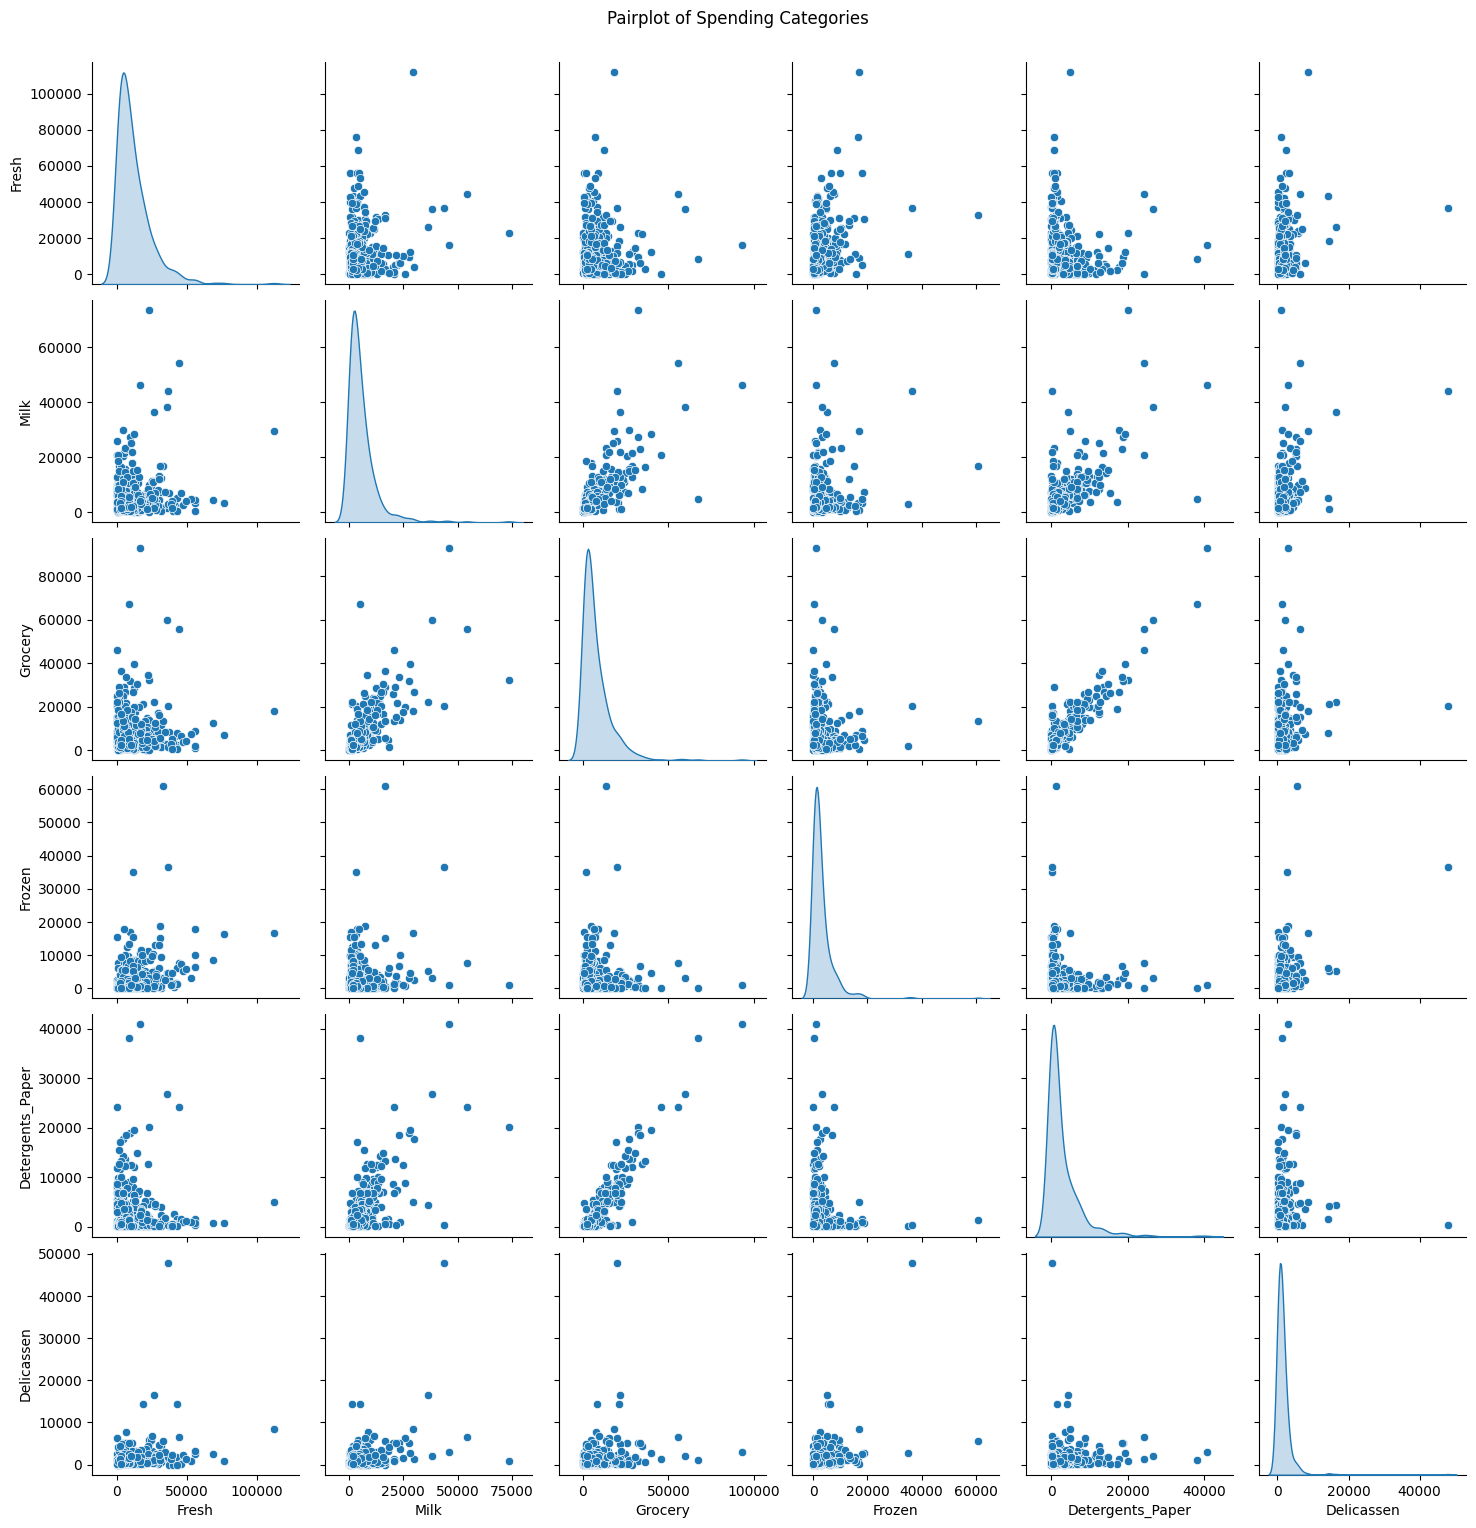

In [8]:
sns.pairplot(df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']], 
             diag_kind='kde')
plt.suptitle('Pairplot of Spending Categories', y=1.02)
plt.show()

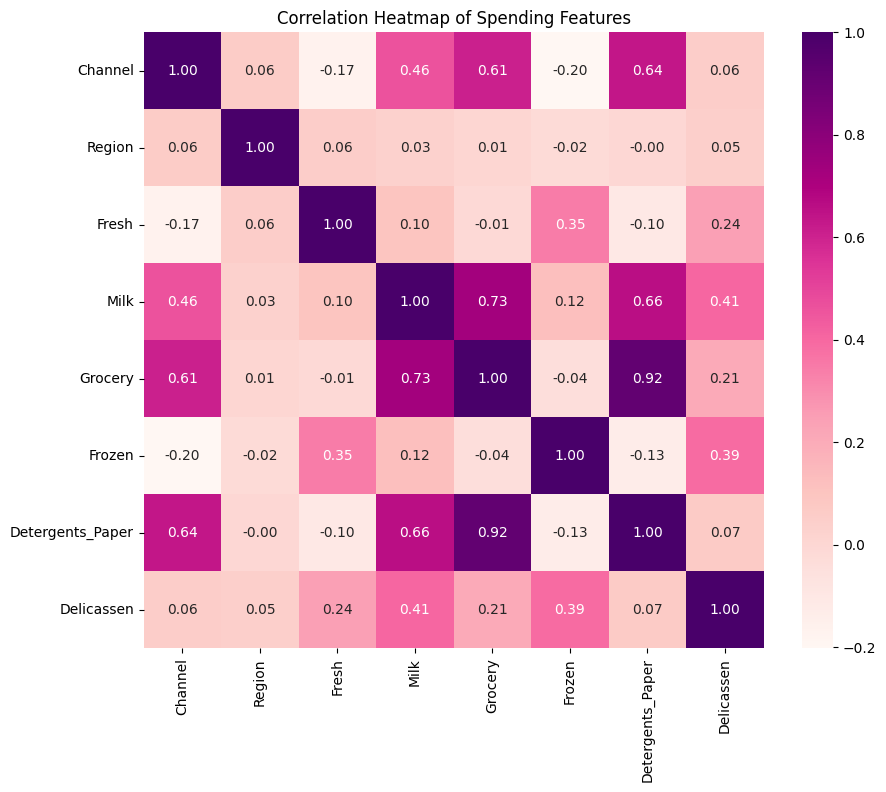

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdPu', fmt='.2f')
plt.title('Correlation Heatmap of Spending Features')
plt.show()

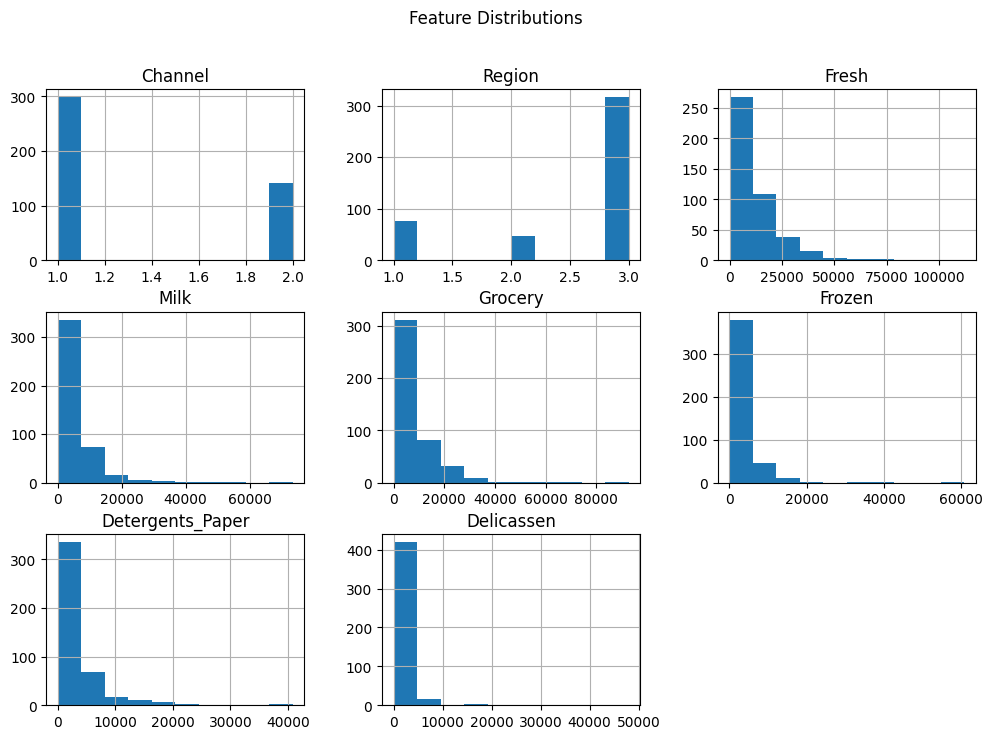

In [10]:
df.hist(figsize=(12, 8), bins=10)
plt.suptitle("Feature Distributions")
plt.show()

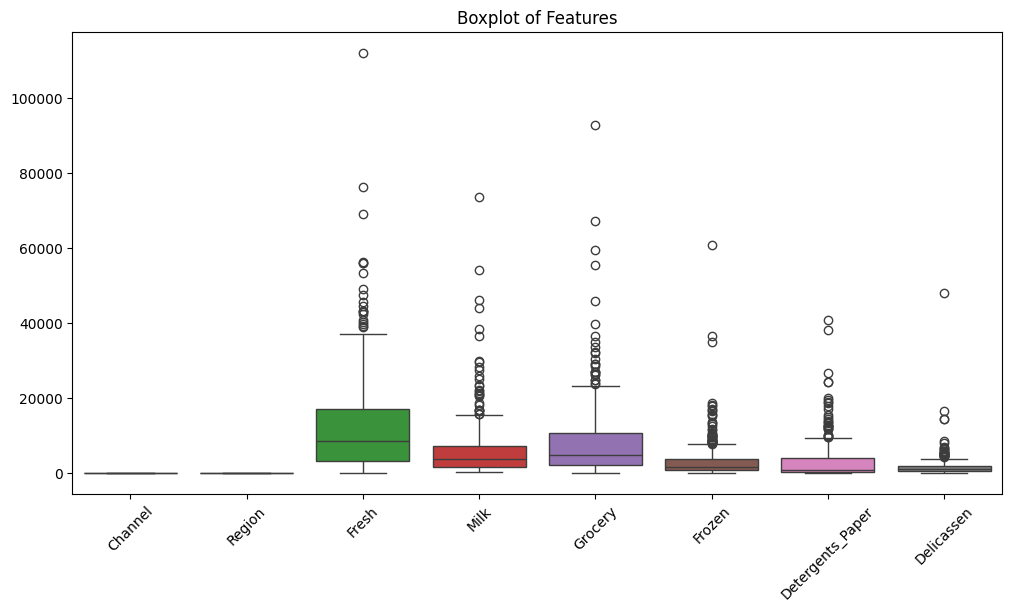

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

In [12]:
#Data Preprocessing
features = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
X = df[features].copy()

In [13]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler

In [14]:
  # StandardScaler

scaler=StandardScaler()
scaled_features = scaler.fit_transform(X)

#print statement
print("Features selected and scaled for clustering")
print(scaled_features[:5])

Features selected and scaled for clustering
[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


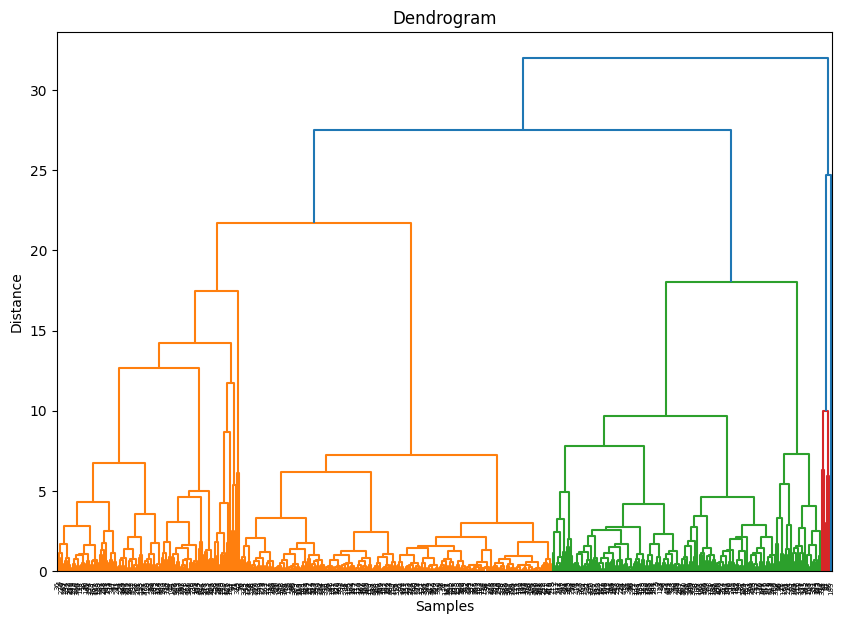

Dendrogram plotted to determine the optimal number of clusters.


In [15]:
from scipy.cluster.hierarchy import linkage , dendrogram

linked=linkage(scaled_features,method='ward')
#plot the dendogram
plt.figure(figsize=(10,7))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()
print("Dendrogram plotted to determine the optimal number of clusters.")

In [16]:
from sklearn.cluster import AgglomerativeClustering

In [17]:
agg_clustering = AgglomerativeClustering(n_clusters=3)
clusters = agg_clustering.fit_predict(scaled_features)

df['clusters'] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,clusters
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


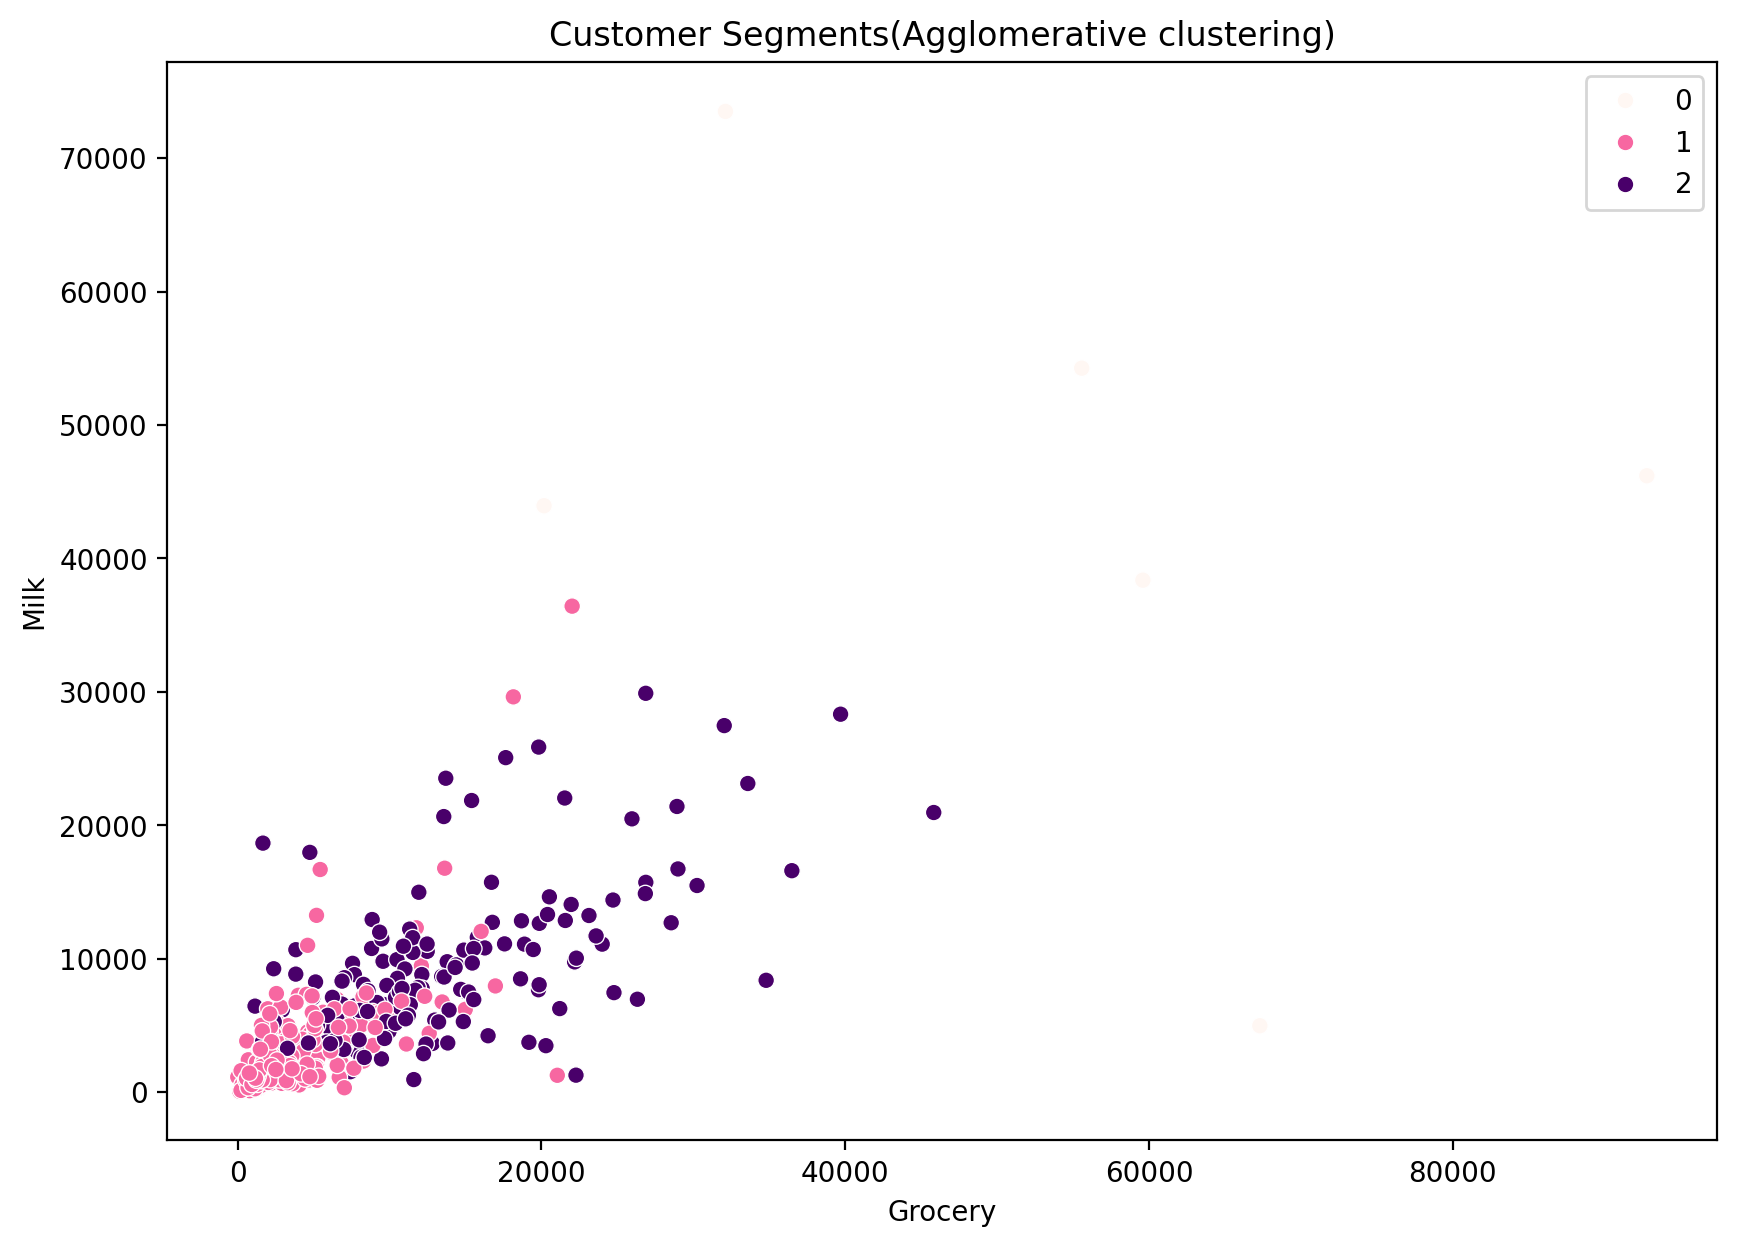

In [18]:
plt.figure(figsize=(10,7),dpi=200)
sns.scatterplot(x='Grocery',y='Milk',hue='clusters',palette='RdPu',data=df)
plt.title('Customer Segments(Agglomerative clustering)')
plt.legend()
plt.show()

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import k_means
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier

In [20]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [21]:
# CORRECT
X = df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y = df['clusters']

In [22]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [23]:

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [32]:
models = {
    'KNeighborsClassifier' : KNeighborsClassifier(n_neighbors=5),
    'DecisionTreeClassifier' : DecisionTreeClassifier(max_depth=5),
    'RandomForestClassifier' : RandomForestClassifier(n_estimators=100),
    'SGDClassifier' : SGDClassifier(loss='hinge',penalty='l2',max_iter=1000)
}

results = []

for model_name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model' : model_name,
        'Accuracy' : round(accuracy_score(y_test,y_pred),4),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
    })

    print(f"\nClassification Report:{model_name}")
    print(classification_report(y_test, y_pred))


results_df = pd.DataFrame(results)
print(results_df)



Classification Report:KNeighborsClassifier
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        57
           2       1.00      0.90      0.95        31

    accuracy                           0.97        88
   macro avg       0.97      0.95      0.96        88
weighted avg       0.97      0.97      0.97        88


Classification Report:DecisionTreeClassifier
              precision    recall  f1-score   support

           1       0.88      1.00      0.93        57
           2       1.00      0.74      0.85        31

    accuracy                           0.91        88
   macro avg       0.94      0.87      0.89        88
weighted avg       0.92      0.91      0.91        88


Classification Report:RandomForestClassifier
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        57
           2       1.00      0.90      0.95        31

    accuracy                           0.97   

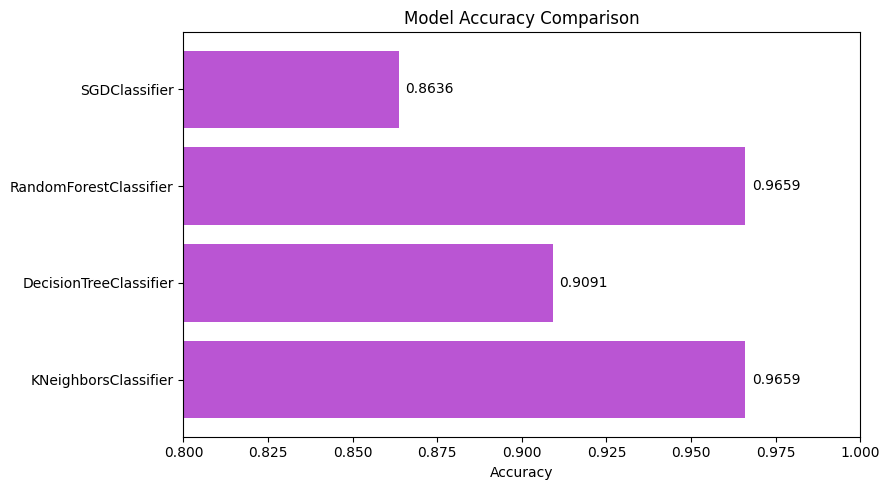

In [25]:
plt.figure(figsize=(9, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color='mediumorchid')
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim(0.8, 1.0)
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
print(results_df.columns.tolist())
print(results_df.head())

['Model', 'Accuracy', 'Confusion Matrix']
                    Model  Accuracy                     Confusion Matrix
0    KNeighborsClassifier    0.9659                   [[57, 0], [3, 28]]
1  DecisionTreeClassifier    0.9091                   [[57, 0], [8, 23]]
2  RandomForestClassifier    0.9659                   [[57, 0], [3, 28]]
3           SGDClassifier    0.8636  [[0, 0, 0], [1, 54, 2], [0, 9, 22]]


In [27]:
import numpy as np

print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2]
[1 2]


In [28]:
# Re-train best model (Random Forest) on full training data
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

print("=== Random Forest — Full Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

=== Random Forest — Full Evaluation ===
Accuracy : 0.9659

Confusion Matrix:
[[57  0]
 [ 3 28]]

Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        57
           2       1.00      0.90      0.95        31

    accuracy                           0.97        88
   macro avg       0.97      0.95      0.96        88
weighted avg       0.97      0.97      0.97        88



In [29]:
import pickle

# Save the trained Random Forest model
with open("wholesale_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save the scaler (fitted on X_train)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model saved  →  wholesale_model.pkl")
print("Scaler saved →  scaler.pkl")

Model saved  →  wholesale_model.pkl
Scaler saved →  scaler.pkl


In [31]:
import pickle
import numpy as np

def infer_customer_segment(input_features):
    """
    Predict the wholesale customer cluster for a new customer.

    Parameters:
    -----------
    input_features : list
        Feature values in this exact order:
        [Channel, Region, Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen]

    Returns:
    --------
    str : Predicted cluster label (0, 1, or 2)
    """
    # Load saved model and scaler
    with open("wholesale_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)

    # Prepare and scale input
    input_array = np.array(input_features).reshape(1, -1)
    scaled_input = scaler.transform(input_array)

    # Predict
    prediction = model.predict(scaled_input)[0]

    cluster_description = {
        0: "Cluster 0 — Moderate spenders (balanced across categories)",
        1: "Cluster 1 — High fresh/frozen buyers (likely restaurants/cafes)",
        2: "Cluster 2 — High grocery/detergent buyers (likely retail stores)"
    }

    print(f"Predicted Cluster  : {prediction}")
    print(f"Segment Description: {cluster_description.get(prediction, 'Unknown')}")
    return prediction


# ── Example Inference ──────────────────────────────────────────────────────────
# Feature order: [Channel, Region, Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen]
sample_customer = [12669, 9656, 7561, 214, 2674, 1338]

result = infer_customer_segment(sample_customer)


Predicted Cluster  : 2
Segment Description: Cluster 2 — High grocery/detergent buyers (likely retail stores)


c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
